In [309]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
import os
os.listdir()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def Read_Data(transform):
    data = pd.read_csv('stars.csv')
    from sklearn.preprocessing import LabelEncoder
    if transform == True:
        le = LabelEncoder()
        # Assign unique integers from 0 to 6 to each star type
        data['Star type'] = le.fit_transform(data['Star type'])
        labels = le.inverse_transform(data['Star type'])
        class_names = le.classes_
        #print(class_names)
        
        data['Spectral Class'] = le.fit_transform(data['Spectral Class'])
        labels = le.inverse_transform(data['Spectral Class'])
        class_names = le.classes_
        #print(class_names)
        
        data['Star color'] = le.fit_transform(data['Star color'])
        labels = le.inverse_transform(data['Star color'])
        class_names = le.classes_
        #print(class_names)
    newCols = np.array( data.columns, dtype=str )
    for i in range(3): newCols[i] = 'log'+newCols[i]
    for i in range(3): data.iloc[:, i] = np.log10(data.iloc[:, i])
    data.columns = newCols
    return data

def sLabel(intLabel):
    i = int(intLabel)
    return ['Brown Dwarf', 'Hypergiant', 'Main Sequence', 'Red Dwarf', 'Supergiant', 'White Dwarf'][i]

Read_Data(True)

,logTemperature (K),logLuminosity(L/Lo),logRadius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3.486855,-2.619789,-0.769551,16.12,0,10,5
1,3.483159,-3.301030,-0.811916,16.60,0,10,5
2,3.414973,-3.522879,-0.991400,18.70,0,10,5
3,3.447158,-3.698970,-0.795880,16.65,0,10,5
4,3.287578,-3.860121,-0.987163,20.06,0,10,5
...,...,...,...,...,...,...,...
235,4.590396,5.573834,3.132260,-9.93,1,0,6
236,4.489100,5.921188,3.077004,-10.63,1,0,6
237,3.945912,5.730373,3.153205,-10.73,1,11,0
238,3.965437,5.607391,3.046105,-11.23,1,11,0


It is often grood practice to start with a statistical analysis of the dataset to answer the following questions:

    - are there any missing values?
    - are there NaNs in the data?

In [186]:
data = Read_Data(transform=True)
for col in data.columns:
    print(col, np.count_nonzero(np.isnan(data[col])))
del data

logTemperature (K) 0
logLuminosity(L/Lo) 0
logRadius(R/Ro) 0
Absolute magnitude(Mv) 0
Star type 0
Star color 0
Spectral Class 0


To-do list:
-    Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
-    Project the dataset into the principal components, and do a scatter plot of the first two.
-    This will look terrible. Think about the units!

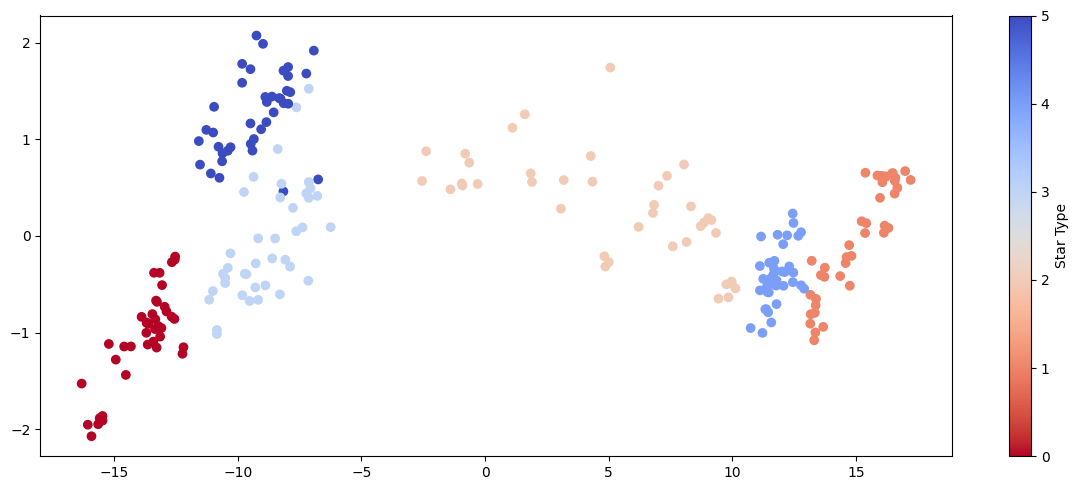

In [188]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA

StarData = Read_Data(transform=True).to_numpy()
tStarData = PCA().fit_transform(StarData[:, :4]) ### only using the T, L, R, Mag data

plt.figure(figsize=(12,5), tight_layout=True)
plt.scatter(tStarData[:, 0], tStarData[:, 1], c=StarData[:, -3], cmap='coolwarm_r')
plt.colorbar(label='Star Type')
del StarData, tStarData

The fact that I am extracting the log10 of each stellar quantity is helping the PCA in performing a better decomposition. In fact, had I left the data in a "raw", "ten-to-the-power-of-something-solar-units" format, the final outcome would have looked much, much worse!

Let's apply the PCA again, this time with a "full" re-scaling approach: mean=0, variance=1 for each column!

In [189]:
def Rescale(array): ### no need, but I could do this instead
    mu  = np.mean(array)
    var = np.var( array)
    return (array-mu) / (var**0.5)

StarData   = Read_Data(transform=True).to_numpy()
StarLabels = StarData[:, 4:]
StarData   = StarData[:, :4]
for j in range(4):
    StarData[:, j] = Rescale(StarData[:, j])

print('Rescaling T, L, R, Mag "by hand"')
for j in range(np.shape(StarData)[1]):
    print( '{0:.1f} {1:.3f}'.format(np.mean(StarData[:, j]), np.var(StarData[:, j])) )

StarData   = Read_Data(transform=True).to_numpy()
StarLabels = StarData[:, 4:]
StarData   = StarData[:, :4]

from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
StarData = Scaler.fit_transform(StarData)

print('Rescaling T, L, R, Mag with StandardScaler')
for j in range(np.shape(StarData)[1]):
    print( '{0:.1f} {1:.3f}'.format(np.mean(StarData[:, j]), np.var(StarData[:, j])) )

del StarData, StarLabels

Rescaling T, L, R, Mag "by hand"
-0.0 1.000
-0.0 1.000
-0.0 1.000
-0.0 1.000
Rescaling T, L, R, Mag with StandardScaler
-0.0 1.000
-0.0 1.000
-0.0 1.000
-0.0 1.000


Ok, regardless of what method I use I have rescaled the data. Let's see what happens now!

Text(0, 0.5, 'Second PCA Component')

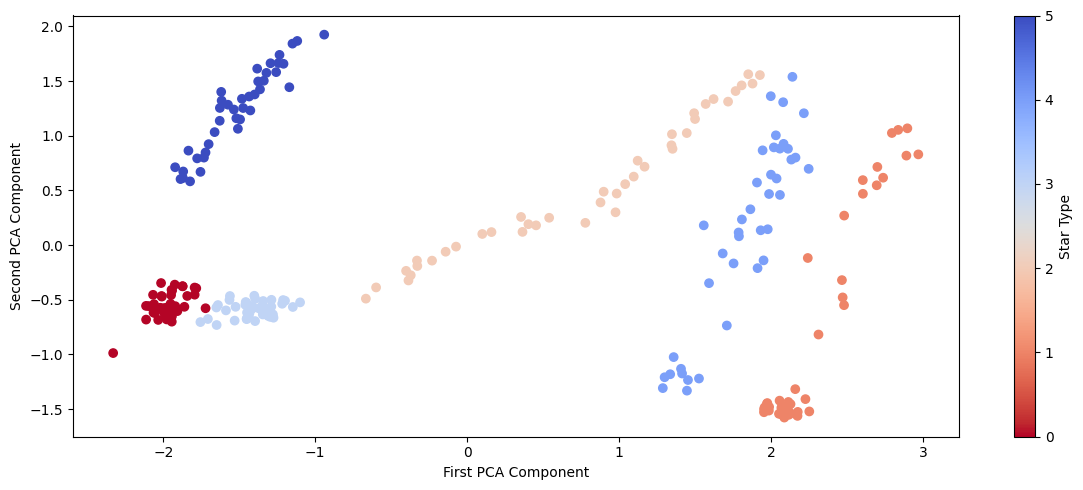

In [224]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA

StarData   = Read_Data(transform=True).to_numpy()
StarLabels = StarData[:, 4:] # logT, logL, logR, Mag
StarData   = StarData[:, :4] # Type, Color, Spectral Class
StarData = Scaler.fit_transform(StarData) ### Rescaling the first 4 columns

aPCA = PCA()#n_components=4)
tStarData = aPCA.fit_transform(StarData)
plt.figure(tight_layout=True, figsize=(12,5))
plt.scatter(tStarData[:, 0], tStarData[:, 1], c=StarLabels[:,0], cmap='coolwarm_r')
plt.colorbar(label='Star Type')
plt.xlabel('First PCA Component')
plt.ylabel('Second PCA Component')

Ok, the histograms are not exactly good-looking but they are indeed with smaller and smaller variances!

Wait a minute: that PCA may look unphysical, but it looks hauntingly familiar.

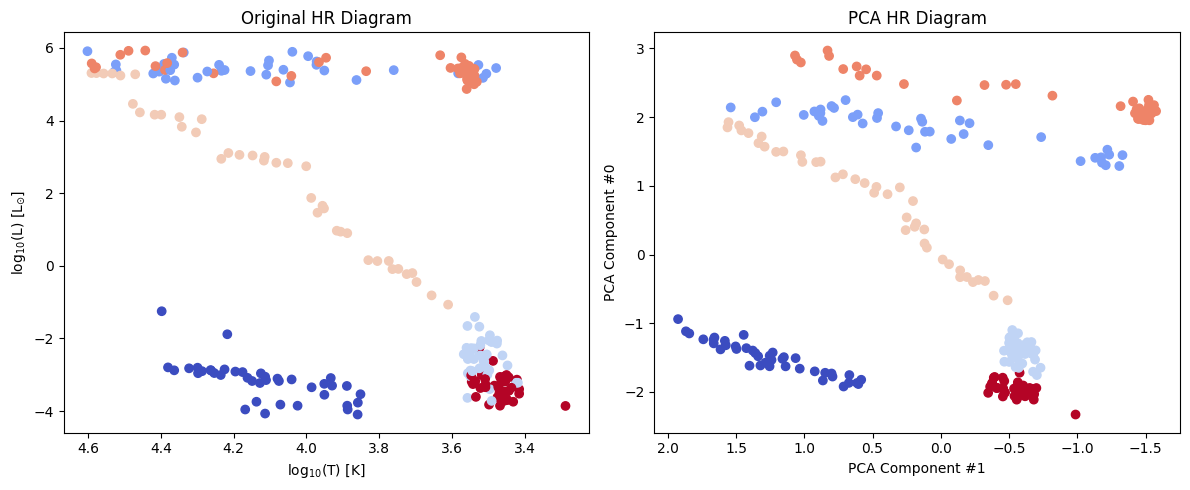

In [227]:
ogData = Read_Data(True)
fig, axs = plt.subplots(1, 2, tight_layout=True, figsize=(12,5))

axs[0].scatter(ogData['logTemperature (K)'], ogData['logLuminosity(L/Lo)'], c=ogData['Star type'], cmap='coolwarm_r')
axs[0].invert_xaxis()
axs[0].set_xlabel(r'log$_{10}$(T) [K]')
axs[0].set_ylabel(r'log$_{10}$(L) [L$_{\odot}$]')
axs[0].set_title('Original HR Diagram')
axs[1].scatter(tStarData[:, 1], tStarData[:, 0], c=StarLabels[:,0], cmap='coolwarm_r')

axs[1].set_xlabel('PCA Component #1')
axs[1].set_ylabel('PCA Component #0')
axs[1].set_title('PCA HR Diagram')
axs[1].invert_xaxis()

Well... I am aware that PCA mixes my original data and produces something "unphysical" or "disconnected" from the original dataset, yet there are some "physical" considerations that we can make by looking at this double-plot.

- To zero order, ALL the properties of a star can be linked to its mass, with different scaling relations. $L\propto M^{3}$, $R \propto M^{\alpha}$ with $\alpha \approx 0.5-0.8$, and so on.

- The PCA #0 Component seems to be "matching" VERY well with the stellar luminosity. As the mass increases linearly, my main-sequence star will climb up the logL axis quite rapidly (unless it's reaching its Eddington Limit, but we don't talk about that here), compared to how its radius scaling or its effective temperature scaling. Therefore, it makes a lot of sense that the luminosity IS indeed responsible for most of the variance in my PCA analysis. Given that the absolute magnitude is basically $M \propto log(L \ d_{L}^{-2})$, component #0 may also be a combination of logL _and_ the absolute magnitude M.

- The PCA #1 Component appears to be "related" with the stellar effective temperature. In this case though, the PCA dataset seems to be separating the star types a bit more. Hence, there may be come "extra" combination of parameters at play.

- The stellar radius does NOT scale as much with the stellar mass, hence it may be in a sub-dominant role in the PCA.

---

Let's add a Scree Plot to check how the variance goes in the components!

Explained Variance      : ['3.059e+00', '8.842e-01', '5.002e-02', '2.327e-02']
Explained Variance Ratio: ['7.616e-01', '2.201e-01', '1.245e-02', '5.793e-03']
The first two components explain  98.1755 % of the variance.


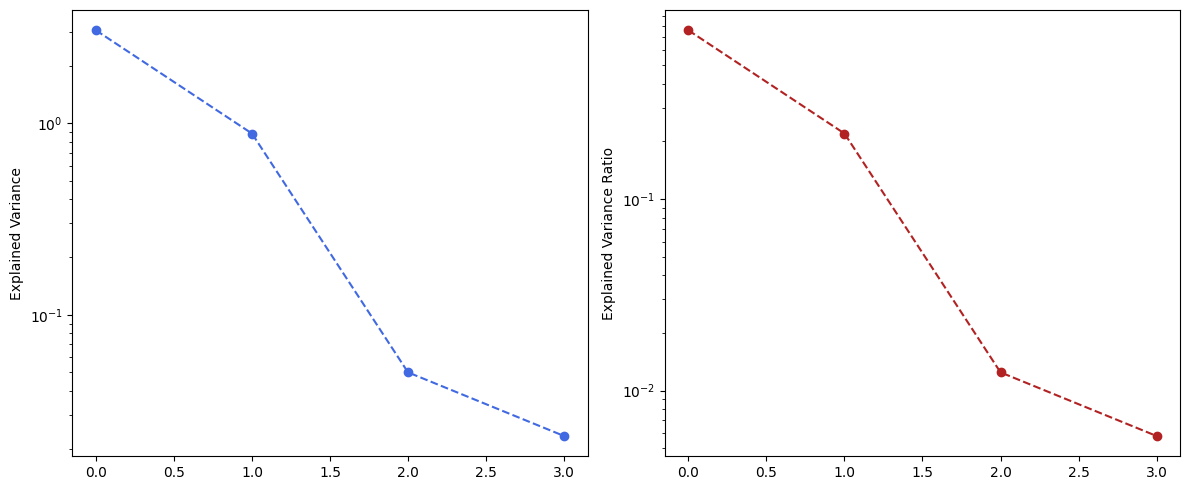

In [228]:
fig, axs = plt.subplots(1, 2, tight_layout=True, figsize=(12,5))

print('Explained Variance      :', ['{0:.3e}'.format(p) for p in aPCA.explained_variance_])
print('Explained Variance Ratio:', ['{0:.3e}'.format(p) for p in aPCA.explained_variance_ratio_ ])
l = np.random.choice(['-', '--', '-.', ':'])
axs[0].plot(np.arange(len(aPCA.singular_values_)),    aPCA.explained_variance_,       c='royalblue', marker='o', ls=l)
axs[1].plot(np.arange(len(aPCA.explained_variance_)), aPCA.explained_variance_ratio_, c='firebrick', marker='o', ls=l)

axs[0].set_ylabel('Explained Variance')
axs[1].set_ylabel('Explained Variance Ratio')

for ax in axs: ax.set_yscale('log')

print('The first two components explain ', '{0:.4f}'.format(100*(aPCA.explained_variance_ratio_[0] + aPCA.explained_variance_ratio_[1])), '% of the variance.')

Is it true, though? Am I really maxing out the variance in the first components? Let's check this!

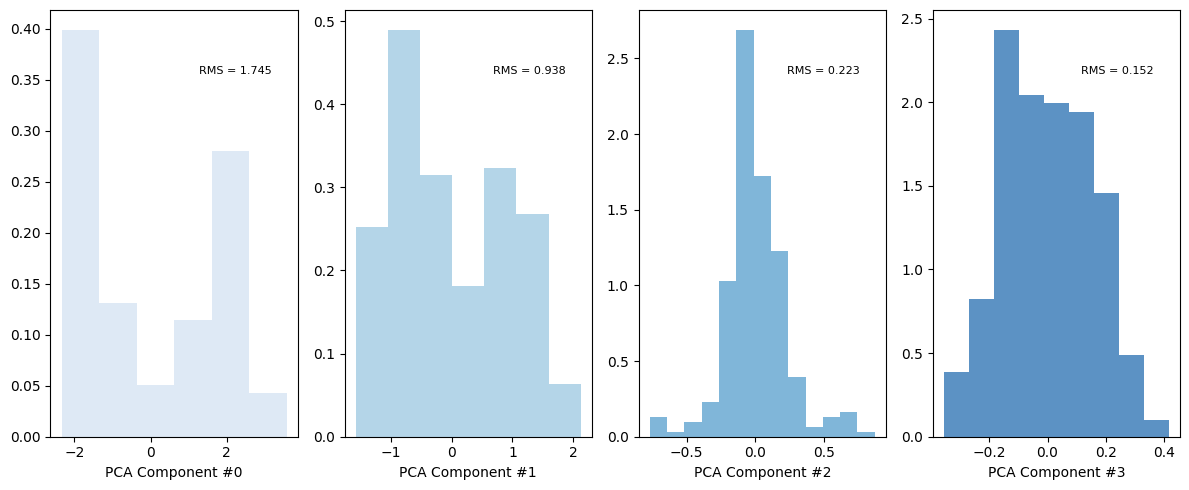

In [229]:
fig, axs = plt.subplots(1, 4, tight_layout=True, figsize=(12,5))
from astropy.visualization import hist
import seaborn as sns
Colors = sns.color_palette('Blues', n_colors=4, as_cmap=False)
for i, ax in enumerate(axs):
    _ = hist(tStarData[:, i], ax=ax, bins='scott', facecolor=Colors[i], alpha=0.7, density=True)
    ax.set_xlabel('PCA Component #' + str(i))
    rms = np.sqrt(np.var(tStarData[:,i]))
    ax.text(x=0.6, y=0.85, s='RMS = {0:.3f}'.format(rms), transform=ax.transAxes, fontsize=8)

Ok, I'd say we're done with PCA. Next step: am I able to predict the star type? My blueprint:

1. Transform the data with a PCA and the re-scaling
2. Run a Classification algorithm on the PCA-transformed data
3. Go back to the original data and compare the results with the original HR diagram.

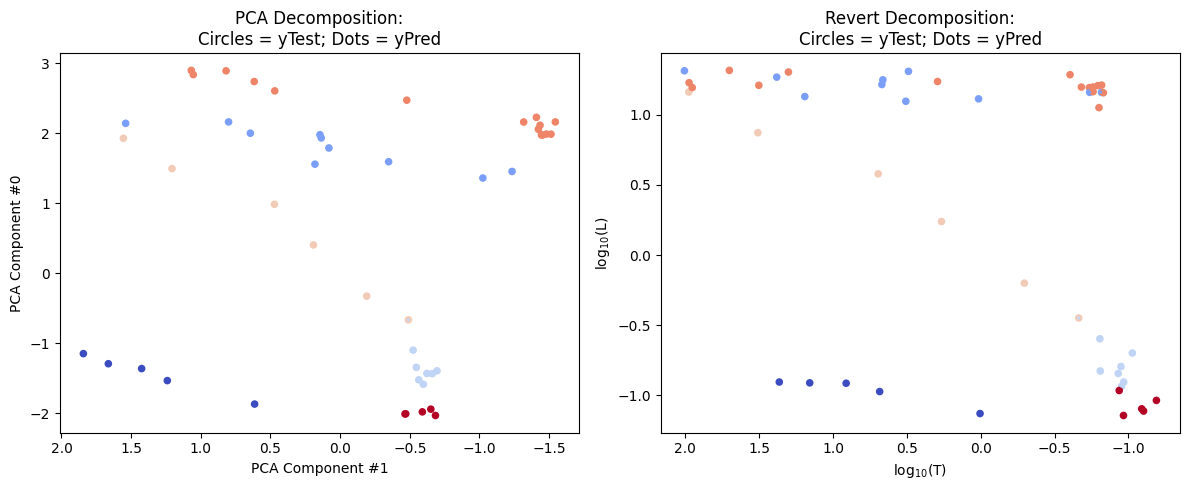

In [356]:
StarData   = Read_Data(transform=True).to_numpy()
StarLabels = StarData[:, 4:] # logT, logL, logR, Mag
StarData   = StarData[:, :4] # Type, Color, Spectral Class
tStarData  = Scaler.fit_transform(StarData) ### Rescaling the first 4 columns

pca = PCA()#n_components=2)
tStarData = pca.fit_transform(tStarData)

from sklearn.model_selection import train_test_split as TTS
Xtrain, Xtest, yTrain, yTest = TTS(tStarData, StarLabels[:, 0], test_size=0.2)

from sklearn.svm import LinearSVC
LSVC = LinearSVC()
LSVC.fit(Xtrain[:, :2], yTrain)
yPred = LSVC.predict(Xtest[:, :2])

fig, axs = plt.subplots(1, 2, tight_layout=True, figsize=(12,5))

axs[0].scatter(Xtest[:, 1], Xtest[:, 0], c=yTest, marker='o', cmap='coolwarm_r', facecolor=(0,0,0,1), s=20)
axs[0].set_title('PCA Decomposition:\n'+'Circles = yTest; Dots = yPred')
axs[0].scatter(Xtest[:, 1], Xtest[:, 0], c=yPred, marker='o', cmap='coolwarm_r', edgecolor=(0,0,0,0), s=5)
axs[0].set_xlabel('PCA Component #1')
axs[0].set_ylabel('PCA Component #0')
axs[0].invert_xaxis()

invXtest = pca.inverse_transform(Xtest)
# print(np.count_nonzero( [x == [-0.99636564, -0.84102771, -0.62951356,  1.11674535] for x in tStarData] ))#invXtest[0,:])
axs[1].scatter(invXtest[:, 0], invXtest[:, 1], c=yTest, marker='o', cmap='coolwarm_r', facecolor=(0,0,0,1), s=20)
axs[1].set_title('PCA Decomposition:\n'+'Circles = yTest; Dots = yPred')
axs[1].scatter(invXtest[:, 0], invXtest[:, 1], c=yPred, marker='o', cmap='coolwarm_r', edgecolor=(0,0,0,0), s=5)
axs[1].set_title('Revert Decomposition:\n'+'Circles = yTest; Dots = yPred')
axs[1].set_ylabel(r'log$_{10}$(L)')
axs[1].set_xlabel(r'log$_{10}$(T)')
axs[1].invert_xaxis()

This is actually really nice, as very few points are in disagreement! Let's plot a confusion matrix, to see how well we did.

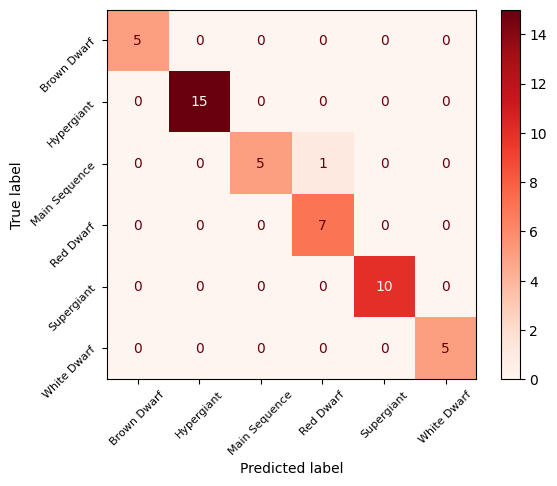

In [357]:
intLabels    = [0,1,2,3,4,5]
stringLabels = np.vectorize(sLabel)(intLabels)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CM = confusion_matrix(yTest, yPred)
ConfusionMatrixDisplay.from_estimator(LSVC, Xtest[:, :2], yTest, cmap='Reds', display_labels=stringLabels)
_ = plt.xticks(fontsize=8, rotation=45)
_ = plt.yticks(fontsize=8, rotation=45)#, norm=True) #(CM)

I mean, this is a naive approach and I could probably improve my performance. In conclusion, I have to say that:

- There are some MS stars that are mistaken for Supergiant stars. Not just any MS star, but the ones "up above" in the HR diagram. Physically speaking, this makes sense.
- A few brown dwarfs are actually red dwarfs: once again, the two classes were already very close to each other in the original dataset.

To improve my results and avoid overfitting, I should probably adopt some cross-validation technique.

(240, 4)
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'C': 100, 'loss': 'squared_hinge', 'max_iter': 10000, 'penalty': 'l2', 'tol': 0.01}
0.9211875843454791
91.66666666666666 %


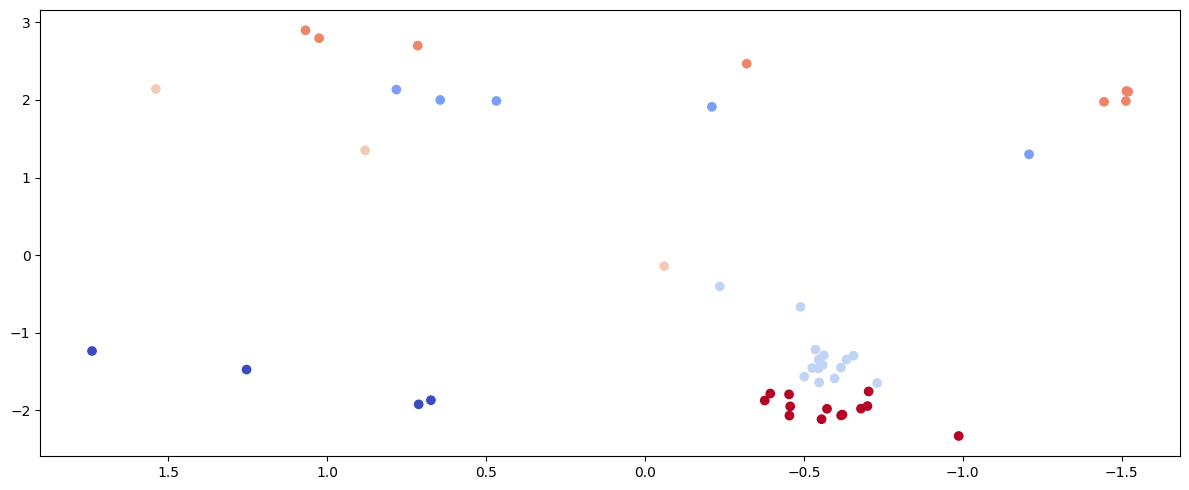

In [404]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

StarData   = Read_Data(transform=True).to_numpy()
StarLabels = StarData[:, 4:] # logT, logL, logR, Mag
StarData   = StarData[:, :4] # Type, Color, Spectral Class
tStarData  = Scaler.fit_transform(StarData) ### Rescaling the first 4 columns

pca = PCA()#n_components=2)
tStarData = pca.fit_transform(tStarData)

Xtrain, Xtest, yTrain, yTest = TTS(tStarData, StarLabels[:, 0], test_size=0.2)
print(np.shape(tStarData))
Classifier = LinearSVC()
param_grid = {'C':[0.01, 0.1, 1, 10, 100, 1000], 'loss':['hinge', 'squared_hinge'], 'penalty':['l2'],
              'tol':[1e-4, 1e-3, 1e-2], 'max_iter':[1000, 5000, 10000]}
GS = GridSearchCV(estimator=Classifier, param_grid=param_grid, cv=5,
                  scoring = 'accuracy', n_jobs=-1, verbose=True)
GS.fit(Xtrain[:, :2], yTrain)
print('Best Params:', GS.best_params_)
print(GS.best_score_)

BestVC = GS.best_estimator_

fig, axs = plt.subplots(tight_layout=True, figsize=(12,5))
model = BestVC
model.fit(Xtrain[:, :2], yTrain)
yPred = model.predict(Xtest[:, :2])
axs.scatter(Xtest[:, 1], Xtest[:, 0], c= yPred, cmap='coolwarm_r')
axs.invert_xaxis()
print(np.count_nonzero(yPred == yTest)/len(yPred)*100, '%')

In [213]:
"""
fig, axs = plt.subplots(2,2, figsize=(12, 12))
axs[0][0].set_title('PCA, w/ no Rescaling')
axs[1][0].set_title('PCA, with Rescaling' )
axs[0][0].scatter(myPCA.components_[0], myPCA.components_[1], s=10) #, c=myData[:, -2], cmap='coolwarm') # these are the centroids
results = myPCA.fit_transform(myData)
print(np.shape(results))
#axs[0][0].scatter(xPlot[:,0], xPlot[:,1], c=cPlot, cmap='coolwarm_r')
myData = Read_Data(transform=True)
for i in range(np.shape(myData)[1]): 
    myData.iloc[:, i] = Rescale(myData.iloc[:, i])

myPCA = PCA(n_components=2)
myPCA.fit(myData)
axs[1][0].scatter(myPCA.components_[0], myPCA.components_[1], s=10)#, c=myData[:,-2], cmap='coolwarm') #, label='rescaled')#, label=)

from sklearn.cluster import KMeans
print(myPCA.get_params())
myPCA.singular_values_

kM = KMeans(n_clusters=6).fit(np.array([myPCA.components_[0], myPCA.components_[1]], dtype=np.double).T)
centroids = kM.cluster_centers_
# print(centroids)
axs[1].scatter(centroids[:,0], centroids[:,1], s=50, c='k')

x_min, x_max = myPCA.components_[0].min(), myPCA.components_[0].max()
y_min, y_max = myPCA.components_[1].min(), myPCA.components_[1].max()
xx, yy = np.meshgrid( np.linspace(x_min, x_max, 100, dtype=np.double), np.linspace(y_min, y_max, 100, dtype=np.double) )
 # print(np.array([xx.ravel(), yy.ravel()]) )
yLabels = kM.predict( np.array([xx.ravel(), yy.ravel()], dtype=np.double).T )
axs[1].scatter(xx, yy, c=yLabels, s=0.25, cmap='coolwarm')
"""

"\nfig, axs = plt.subplots(2,2, figsize=(12, 12))\naxs[0][0].set_title('PCA, w/ no Rescaling')\naxs[1][0].set_title('PCA, with Rescaling' )\naxs[0][0].scatter(myPCA.components_[0], myPCA.components_[1], s=10) #, c=myData[:, -2], cmap='coolwarm') # these are the centroids\nresults = myPCA.fit_transform(myData)\nprint(np.shape(results))\n#axs[0][0].scatter(xPlot[:,0], xPlot[:,1], c=cPlot, cmap='coolwarm_r')\nmyData = Read_Data(transform=True)\nfor i in range(np.shape(myData)[1]): \n    myData.iloc[:, i] = Rescale(myData.iloc[:, i])\n\nmyPCA = PCA(n_components=2)\nmyPCA.fit(myData)\naxs[1][0].scatter(myPCA.components_[0], myPCA.components_[1], s=10)#, c=myData[:,-2], cmap='coolwarm') #, label='rescaled')#, label=)\n\nfrom sklearn.cluster import KMeans\nprint(myPCA.get_params())\nmyPCA.singular_values_\n\nkM = KMeans(n_clusters=6).fit(np.array([myPCA.components_[0], myPCA.components_[1]], dtype=np.double).T)\ncentroids = kM.cluster_centers_\n# print(centroids)\naxs[1].scatter(centroids[:,0

In [212]:
"""
data = Read_Data(transform=True)
xData = data['logTemperature (K)']
yData = data['logLuminosity(L/Lo)']
X = np.array([xData, yData], dtype=float).T
y = np.array(data['Star type'])

from sklearn.model_selection import train_test_split as TTS
Xtrain, Xtest, yTrain, yTest = TTS(X, y, test_size=0.2)
fig, axs = plt.subplots(1,2, figsize=(14,7), tight_layout=True, sharex=True, sharey=True)

import seaborn as sns
Blues = sns.color_palette('BuGn', n_colors=6, as_cmap=False)# [3:]
Reds  = sns.color_palette('GnBu', n_colors=6, as_cmap=False)#[3:]

for ax in axs: 
    ax.scatter(xData, yData, s=25, marker='o', c=[Blues[sType] for sType in data['Star type']]) #, cmap=Blues)
    ax.set_xlabel(r'$log_{10}(T) \ [ \ K \ ]$')
    ax.set_ylabel(r'$log_{10} \left( \frac{L}{L_{\odot}} \right)$')
axs[0].invert_xaxis()

from sklearn.cluster import KMeans
kM = KMeans(n_clusters=6).fit(Xtrain)
centroids = kM.cluster_centers_
# print(centroids)
axs[0].scatter(centroids[:,0], centroids[:,1], s=100, marker='x', c='k')

x_min, x_max = np.min(xData), np.max(xData)#myPCA.components_[0].min(), myPCA.components_[0].max()
y_min, y_max = np.min(yData), np.max(yData)#myPCA.components_[1].min(), myPCA.components_[1].max()
xx, yy = np.meshgrid( np.linspace(x_min, x_max, 250, dtype=np.double), np.linspace(y_min, y_max, 250, dtype=float) )
 # print(np.array([xx.ravel(), yy.ravel()]) )
yLabels = kM.predict( np.array([xx.ravel(), yy.ravel()], dtype=float).T )
axs[0].scatter(xx, yy, s=0.10, c=[Reds[yLab] for yLab in yLabels], alpha=0.6)
axs[0].set_title('Unsupervised Clustering, NO PCA')

from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

LR.fit(Xtrain, yTrain)
yLabels = LR.predict( np.array([xx.ravel(), yy.ravel()]).T )
axs[1].scatter(xx, yy, s=0.10, c=[Reds[yLab] for yLab in yLabels], alpha=0.6)
axs[1].set_title('Supervised Classification, NO PCA')
"""

"\ndata = Read_Data(transform=True)\nxData = data['logTemperature (K)']\nyData = data['logLuminosity(L/Lo)']\nX = np.array([xData, yData], dtype=float).T\ny = np.array(data['Star type'])\n\nfrom sklearn.model_selection import train_test_split as TTS\nXtrain, Xtest, yTrain, yTest = TTS(X, y, test_size=0.2)\nfig, axs = plt.subplots(1,2, figsize=(14,7), tight_layout=True, sharex=True, sharey=True)\n\nimport seaborn as sns\nBlues = sns.color_palette('BuGn', n_colors=6, as_cmap=False)# [3:]\nReds  = sns.color_palette('GnBu', n_colors=6, as_cmap=False)#[3:]\n\nfor ax in axs: \n    ax.scatter(xData, yData, s=25, marker='o', c=[Blues[sType] for sType in data['Star type']]) #, cmap=Blues)\n    ax.set_xlabel(r'$log_{10}(T) \\ [ \\ K \\ ]$')\n    ax.set_ylabel(r'$log_{10} \\left( \x0crac{L}{L_{\\odot}} \right)$')\naxs[0].invert_xaxis()\n\nfrom sklearn.cluster import KMeans\nkM = KMeans(n_clusters=6).fit(Xtrain)\ncentroids = kM.cluster_centers_\n# print(centroids)\naxs[0].scatter(centroids[:,0], c